# Tarea 1 - Inteligencia Artificial
## Parte 1: Redes Bayesianas

**Estudiante(s):** Vicente Díaz, Fernanda Valencia

**Fecha:** Abril 2026

---

## Dataset: Women's E-Commerce Clothing Reviews

Este dataset contiene más de 23.000 reseñas de ropa femenina publicadas en una plataforma de comercio electrónico. Cada fila corresponde a una reseña e incluye información sobre el artículo, la edad de quien escribe, la calificación otorgada, si el producto es recomendado o no, la cantidad de votos positivos recibidos y la categoría a la que pertenece el artículo.

In [1]:
!pip install pgmpy pandas numpy matplotlib seaborn scikit-learn networkx

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import ExhaustiveSearch, HillClimbSearch
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.inference import VariableElimination
from pgmpy.sampling import BayesianModelSampling
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

c:\Users\ferna\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ferna\AppData\Local\Programs\Python\Python313\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


## 1. Carga y Exploración del Dataset

Se carga el dataset directamente desde el archivo CSV y se realiza una revisión inicial de su estructura, tipos de datos y estadísticas descriptivas básicas.

In [3]:
df = pd.read_csv('Womens Clothing E-Commerce Reviews.csv', index_col=0)

print(f"Dimensiones del dataset: {df.shape}")
print(f"\nPrimeras filas:")
df.head()

Dimensiones del dataset: (23486, 10)

Primeras filas:


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
print("Información del dataset:")
df.info()
print("\n" + "="*50)
print("Estadísticas descriptivas:")
df.describe()

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              23486 non-null  int64
 1   Age                      23486 non-null  int64
 2   Title                    19676 non-null  str  
 3   Review Text              22641 non-null  str  
 4   Rating                   23486 non-null  int64
 5   Recommended IND          23486 non-null  int64
 6   Positive Feedback Count  23486 non-null  int64
 7   Division Name            23472 non-null  str  
 8   Department Name          23472 non-null  str  
 9   Class Name               23472 non-null  str  
dtypes: int64(5), str(5)
memory usage: 1.8 MB

Estadísticas descriptivas:


,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,918.118709,43.198544,4.196032,0.822362,2.535936
std,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


In [5]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal de filas: {len(df)}")
print(f"Total de columnas: {df.shape[1]}")

Valores nulos por columna:
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

Total de filas: 23486
Total de columnas: 10


## 2. Preprocesamiento de Datos

Para poder construir la Red Bayesiana es necesario trabajar exclusivamente con variables categóricas. Las variables numéricas continuas deben discretizarse y los valores faltantes deben eliminarse o imputarse.

De las 10 columnas disponibles se seleccionaron **7** que resultan relevantes para modelar las relaciones de interés:

- **Age** → discretizada en grupos etarios: 18-25, 26-35, 36-45, 46-55, 56+
- **Rating** → se conserva como variable ordinal (1 a 5)
- **Recommended IND** → binarizada en Sí / No
- **Positive Feedback Count** → discretizada en niveles: None, Low, Medium, High
- **Division Name** → variable categórica original
- **Department Name** → variable categórica original
- **Class Name** → variable categórica original

Se descartan `Title` y `Review Text` por ser texto libre, y `Clothing ID` por ser un identificador sin valor predictivo.
Las filas con valores nulos en cualquiera de las columnas seleccionadas se eliminan, lo que resulta en un dataset limpio de 23.472 registros.

In [6]:
columnas_utiles = ['Age', 'Rating', 'Recommended IND', 'Positive Feedback Count', 
                   'Division Name', 'Department Name', 'Class Name']

df_bn = df[columnas_utiles].copy()

df_bn = df_bn.dropna()

print(f"Dataset después de limpieza: {df_bn.shape}")
print(f"\nValores nulos restantes: {df_bn.isnull().sum().sum()}")

Dataset después de limpieza: (23472, 7)

Valores nulos restantes: 0


In [7]:
df_bn['Age_Group'] = pd.cut(df_bn['Age'], 
                             bins=[0, 25, 35, 45, 55, 100], 
                             labels=['18-25', '26-35', '36-45', '46-55', '56+'])

df_bn['Feedback_Level'] = pd.cut(df_bn['Positive Feedback Count'], 
                                  bins=[-1, 0, 5, 15, 1000], 
                                  labels=['None', 'Low', 'Medium', 'High'])

df_bn['Rating_Cat'] = df_bn['Rating'].astype(str)

df_bn['Recommended'] = df_bn['Recommended IND'].map({0: 'No', 1: 'Yes'})

df_discreto = df_bn[['Age_Group', 'Rating_Cat', 'Recommended', 'Feedback_Level', 
                     'Division Name', 'Department Name', 'Class Name']].copy()

df_discreto.columns = ['Age_Group', 'Rating', 'Recommended', 'Feedback', 
                       'Division', 'Department', 'Class']

df_discreto = df_discreto.astype(str)

df_discreto = df_discreto.replace('nan', np.nan).dropna()

print(f"Dataset discretizado: {df_discreto.shape}")
print(f"\nPrimeras filas:")
df_discreto.head()

Dataset discretizado: (23472, 7)

Primeras filas:


,Age_Group,Rating,Recommended,Feedback,Division,Department,Class
0,26-35,4,Yes,None,Initmates,Intimate,Intimates
1,26-35,5,Yes,Low,General,Dresses,Dresses
2,56+,3,No,None,General,Dresses,Dresses
3,46-55,5,Yes,None,General Petite,Bottoms,Pants
4,46-55,5,Yes,Medium,General,Tops,Blouses


In [8]:
print("Valores únicos por columna:")
for col in df_discreto.columns:
    print(f"\n{col}: {df_discreto[col].nunique()} valores únicos")
    print(f"  Valores: {df_discreto[col].unique()[:10]}")

Valores únicos por columna:

Age_Group: 5 valores únicos
  Valores: <StringArray>
['26-35', '56+', '46-55', '36-45', '18-25']
Length: 5, dtype: str

Rating: 5 valores únicos
  Valores: <StringArray>
['4', '5', '3', '2', '1']
Length: 5, dtype: str

Recommended: 2 valores únicos
  Valores: <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Feedback: 4 valores únicos
  Valores: <StringArray>
['None', 'Low', 'Medium', 'High']
Length: 4, dtype: str

Division: 3 valores únicos
  Valores: <StringArray>
['Initmates', 'General', 'General Petite']
Length: 3, dtype: str

Department: 6 valores únicos
  Valores: <StringArray>
['Intimate', 'Dresses', 'Bottoms', 'Tops', 'Jackets', 'Trend']
Length: 6, dtype: str

Class: 20 valores únicos
  Valores: <StringArray>
[ 'Intimates',    'Dresses',      'Pants',    'Blouses',      'Knits',
  'Outerwear',     'Lounge',   'Sweaters',     'Skirts', 'Fine gauge']
Length: 10, dtype: str


## 3. Aprendizaje de Estructura: Búsqueda Exhaustiva (ExhaustiveSearch)

### ¿Qué hace este método?

**ExhaustiveSearch** recorre *todos* los posibles grafos acíclicos dirigidos (DAGs) formados por las variables del dataset y selecciona aquel que maximiza una métrica de puntuación, habitualmente BIC o K2.

El procedimiento es el siguiente:
1. Se enumeran todos los DAGs posibles para el conjunto de variables dado.
2. Para cada estructura se calcula el score (en este caso, el predeterminado de pgmpy).
3. Se devuelve la estructura con la puntuación más alta.

**Ventajas:**
- Garantiza encontrar la estructura óptima según el criterio elegido.
- No depende de ninguna inicialización aleatoria.

**Desventajas:**
- La cantidad de DAGs posibles crece de forma superexponencial con el número de variables. Para *n* = 5 ya hay miles de grafos candidatos; para *n* = 10 el número se vuelve completamente inmanejable.
- El costo computacional hace que sea impráctica en datasets con más de 5 o 6 variables.

### Justificación de la reducción a 5 variables

Dado que ExhaustiveSearch tiene complejidad superexponencial, se optó por trabajar con un subconjunto de **5 variables**: Rating, Recommended, Feedback, Division y Department. Se descartaron `Age_Group` y `Class` porque, aunque aportan información, la relación entre calificación, recomendación y nivel de feedback ya captura el núcleo del fenómeno de interés. Incluir más variables habría hecho el proceso prohibitivamente lento sin un aporte proporcional en la calidad del modelo.

In [9]:
columnas_exhaustive = ['Rating', 'Recommended', 'Feedback', 'Division', 'Department']
df_exhaustive = df_discreto[columnas_exhaustive].copy()

print(f"Dataset para ExhaustiveSearch: {df_exhaustive.shape}")
print(f"Variables seleccionadas: {list(df_exhaustive.columns)}")

Dataset para ExhaustiveSearch: (23472, 5)
Variables seleccionadas: ['Rating', 'Recommended', 'Feedback', 'Division', 'Department']


In [10]:
import time

print("Ejecutando ExhaustiveSearch...")
print("Nota: Este proceso puede tomar varios minutos debido a la naturaleza exhaustiva del algoritmo.\n")

inicio = time.time()
df_exhaustive = df_exhaustive.astype('category')
#scoring_method = BicScore(df_exhaustive)
exhaustive_search = ExhaustiveSearch(df_exhaustive)
best_model_exhaustive = exhaustive_search.estimate()

fin = time.time()

print(f"ExhaustiveSearch completado en {fin-inicio:.2f} segundos")
print(f"\nEstructura encontrada (aristas):")
print(best_model_exhaustive.edges())

Ejecutando ExhaustiveSearch...
Nota: Este proceso puede tomar varios minutos debido a la naturaleza exhaustiva del algoritmo.

ExhaustiveSearch completado en 97.21 segundos

Estructura encontrada (aristas):
[('Department', 'Division'), ('Department', 'Feedback'), ('Feedback', 'Recommended'), ('Recommended', 'Rating')]


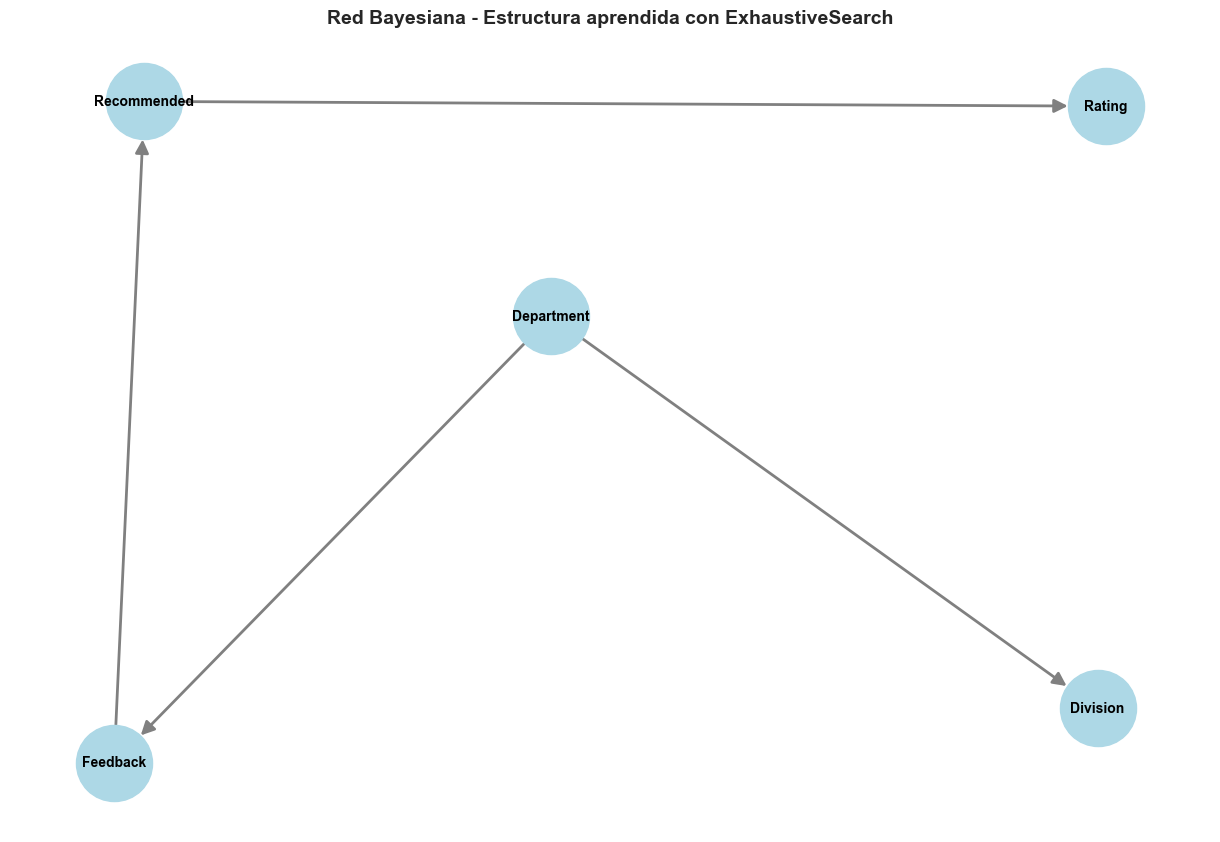


Número de aristas: 4
Nodos: ['Department', 'Division', 'Feedback', 'Rating', 'Recommended']


In [11]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(12, 8))
G_exhaustive = nx.DiGraph(best_model_exhaustive.edges())
pos = nx.spring_layout(G_exhaustive, k=2, iterations=50, seed=42)

nx.draw(G_exhaustive, pos, 
        with_labels=True, 
        node_color='lightblue', 
        node_size=3000, 
        font_size=10, 
        font_weight='bold',
        arrows=True,
        arrowsize=20,
        edge_color='gray',
        width=2)

plt.title("Red Bayesiana - Estructura aprendida con ExhaustiveSearch", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nNúmero de aristas: {len(best_model_exhaustive.edges())}")
print(f"Nodos: {list(best_model_exhaustive.nodes())}")

## 4. Aprendizaje de Estructura: Hill Climbing Search

### ¿Qué hace este método?

**HillClimbSearch** es un algoritmo de búsqueda local que construye la estructura de la red de forma iterativa. A diferencia de ExhaustiveSearch, no evalúa todas las estructuras posibles, sino que parte de un grafo inicial (generalmente vacío) y en cada paso aplica la modificación que más mejore el score actual.

En cada iteración el algoritmo evalúa tres tipos de operaciones sobre las aristas:
- **Agregar** una arista que no exista.
- **Eliminar** una arista existente.
- **Invertir** la dirección de una arista existente.

El proceso se repite hasta que ninguna de estas operaciones logra mejorar el score, momento en que se considera que el algoritmo ha convergido.

**Ventajas:**
- Mucho más eficiente que ExhaustiveSearch; su costo es polinomial en la práctica.
- Escala bien con datasets que tienen muchas variables.

**Desventajas:**
- Al ser una búsqueda local, puede quedar atrapado en óptimos locales y no encontrar necesariamente la estructura global óptima.
- El resultado puede variar según la estructura inicial utilizada.

Gracias a esta eficiencia, HillClimbSearch puede trabajar con las **7 variables** del dataset sin inconvenientes.

In [12]:
df_discreto = df_discreto.astype('category')
hc_search = HillClimbSearch(df_discreto)
print(f"Dataset para HillClimbSearch: {df_discreto.shape}")
print(f"Variables: {list(df_discreto.columns)}\n")

print("Ejecutando HillClimbSearch...\n")

inicio = time.time()

best_model_hc = hc_search.estimate()
fin = time.time()

print(f"✓ HillClimbSearch completado en {fin-inicio:.2f} segundos")
print(f"\nEstructura encontrada (aristas):")
print(best_model_hc.edges())

Dataset para HillClimbSearch: (23472, 7)
Variables: ['Age_Group', 'Rating', 'Recommended', 'Feedback', 'Division', 'Department', 'Class']

Ejecutando HillClimbSearch...



  0%|          | 5/1000000 [00:00<39:57:09,  6.95it/s] 

✓ HillClimbSearch completado en 0.76 segundos

Estructura encontrada (aristas):
[('Rating', 'Recommended'), ('Recommended', 'Feedback'), ('Feedback', 'Age_Group'), ('Class', 'Department'), ('Class', 'Division')]


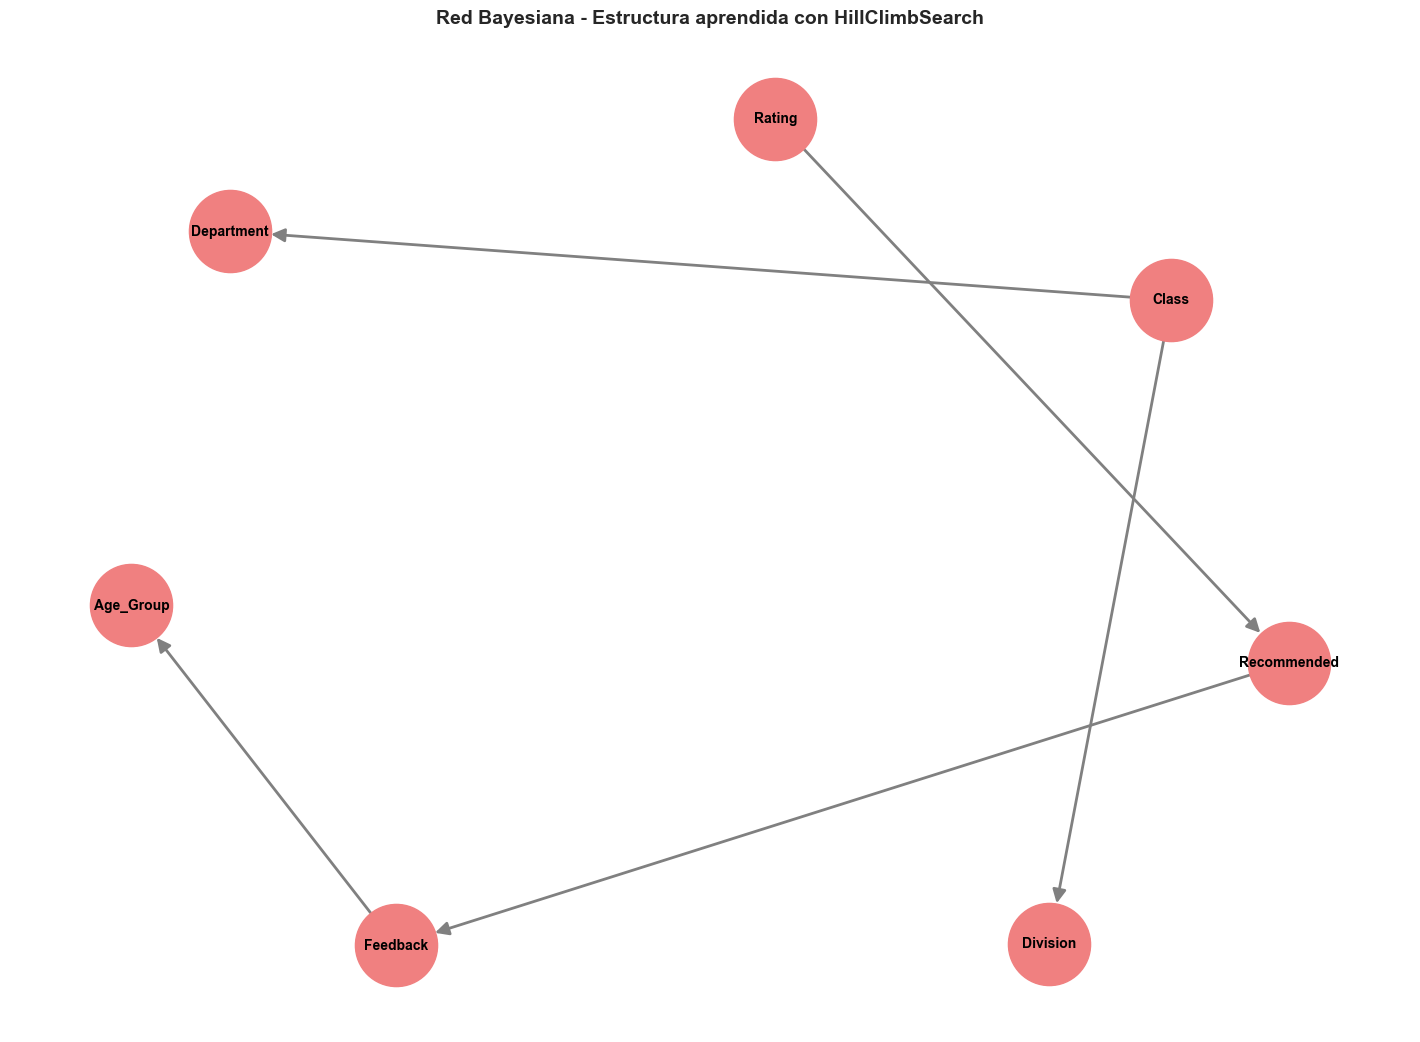


Número de aristas: 5
Nodos: ['Age_Group', 'Rating', 'Recommended', 'Feedback', 'Division', 'Department', 'Class']


In [13]:
plt.figure(figsize=(14, 10))
G_hc = nx.DiGraph(best_model_hc.edges())
pos = nx.spring_layout(G_hc, k=3, iterations=50, seed=42)

nx.draw(G_hc, pos, 
        with_labels=True, 
        node_color='lightcoral', 
        node_size=3500, 
        font_size=10, 
        font_weight='bold',
        arrows=True,
        arrowsize=20,
        edge_color='gray',
        width=2)

plt.title("Red Bayesiana - Estructura aprendida con HillClimbSearch", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nNúmero de aristas: {len(best_model_hc.edges())}")
print(f"Nodos: {list(best_model_hc.nodes())}")

## 5. Estimación de Parámetros

Una vez definida la estructura de la red (qué variables son padres de cuáles), se estiman las **distribuciones de probabilidad condicional (CPDs)** de cada nodo.

Se utiliza **Maximum Likelihood Estimation (MLE)**, que calcula las probabilidades directamente a partir de las frecuencias observadas en el dataset. Para cada nodo, la CPD indica la probabilidad de cada valor posible condicionada a los valores de sus nodos padre.

El proceso se realiza para ambos modelos: el obtenido con ExhaustiveSearch y el obtenido con HillClimbSearch.

In [14]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator

model_exhaustive = DiscreteBayesianNetwork(best_model_exhaustive.edges())
model_hc = DiscreteBayesianNetwork(best_model_hc.edges())

print("Estimando parámetros para modelo ExhaustiveSearch...")
model_exhaustive.fit(df_exhaustive, estimator=MaximumLikelihoodEstimator)
print("Parámetros estimados\n")

print("Estimando parámetros para modelo HillClimbSearch...")
model_hc.fit(df_discreto, estimator=MaximumLikelihoodEstimator)
print("Parámetros estimados")

Estimando parámetros para modelo ExhaustiveSearch...
Parámetros estimados

Estimando parámetros para modelo HillClimbSearch...
Parámetros estimados


In [15]:
print("="*80)
print("CPDs del modelo ExhaustiveSearch (primeras 3):")
print("="*80)
for i, cpd in enumerate(model_exhaustive.get_cpds()[:3]):
    print(f"\n{i+1}. CPD de {cpd.variable}:")
    print(cpd)

CPDs del modelo ExhaustiveSearch (primeras 3):

1. CPD de Department:
+----------------------+------------+
| Department(Bottoms)  | 0.161852   |
+----------------------+------------+
| Department(Dresses)  | 0.269214   |
+----------------------+------------+
| Department(Intimate) | 0.0739179  |
+----------------------+------------+
| Department(Jackets)  | 0.0439673  |
+----------------------+------------+
| Department(Tops)     | 0.445978   |
+----------------------+------------+
| Department(Trend)    | 0.00506987 |
+----------------------+------------+

2. CPD de Division:
+--------------------------+-----+---------------------+
| Department               | ... | Department(Trend)   |
+--------------------------+-----+---------------------+
| Division(General)        | ... | 0.8067226890756303  |
+--------------------------+-----+---------------------+
| Division(General Petite) | ... | 0.19327731092436976 |
+--------------------------+-----+---------------------+
| Division(Initm

In [16]:
print("="*80)
print("CPDs del modelo HillClimbSearch (primeras 3):")
print("="*80)
for i, cpd in enumerate(model_hc.get_cpds()[:3]):
    print(f"\n{i+1}. CPD de {cpd.variable}:")
    print(cpd)

CPDs del modelo HillClimbSearch (primeras 3):

1. CPD de Rating:
+-----------+-----------+
| Rating(1) | 0.0358725 |
+-----------+-----------+
| Rating(2) | 0.0666752 |
+-----------+-----------+
| Rating(3) | 0.122316  |
+-----------+-----------+
| Rating(4) | 0.2163    |
+-----------+-----------+
| Rating(5) | 0.558836  |
+-----------+-----------+

2. CPD de Recommended:
+------------------+-----+----------------------+
| Rating           | ... | Rating(5)            |
+------------------+-----+----------------------+
| Recommended(No)  | ... | 0.001905923610581688 |
+------------------+-----+----------------------+
| Recommended(Yes) | ... | 0.9980940763894183   |
+------------------+-----+----------------------+

3. CPD de Feedback:
+------------------+---------------------+----------------------+
| Recommended      | Recommended(No)     | Recommended(Yes)     |
+------------------+---------------------+----------------------+
| Feedback(High)   | 0.04554170661553212 | 0.02647668393

## 6. Inferencias a Posteriori

Con los parámetros estimados se pueden realizar consultas probabilísticas sobre la red. Se usa **Variable Elimination**, un algoritmo exacto de inferencia que calcula la distribución marginal de una variable de interés dado un conjunto de evidencias observadas.

Se realizan **dos inferencias por modelo** (cuatro en total), eligiendo preguntas que permitan comparar el comportamiento de ambas redes frente a evidencias similares.

In [17]:
infer_exhaustive = VariableElimination(model_exhaustive)
infer_hc = VariableElimination(model_hc)

### 6.1 Inferencias en el modelo ExhaustiveSearch

Las dos consultas apuntan a relaciones centrales del dataset: el vínculo entre la calificación y la probabilidad de recomendación, y el efecto conjunto de la recomendación y el rating alto sobre el nivel de feedback.

In [18]:
print("Inferencia 1 - ExhaustiveSearch")
print("¿Cuál es la probabilidad de que un producto sea recomendado dado que tiene Rating = 5?")

resultado1_ex = infer_exhaustive.query(variables=['Recommended'], evidence={'Rating': '5'})
print(resultado1_ex)

prob_yes = resultado1_ex.values[1]  # Probabilidad de "Yes"
print(f"\nInterpretación: Hay un {prob_yes*100:.2f}% de probabilidad de que un producto con calificación 5 sea recomendado.")

Inferencia 1 - ExhaustiveSearch
¿Cuál es la probabilidad de que un producto sea recomendado dado que tiene Rating = 5?
+------------------+--------------------+
| Recommended      |   phi(Recommended) |
+==================+====================+
| Recommended(No)  |             0.0019 |
+------------------+--------------------+
| Recommended(Yes) |             0.9981 |
+------------------+--------------------+

Interpretación: Hay un 99.81% de probabilidad de que un producto con calificación 5 sea recomendado.


In [19]:
print("Inferencia 2 - ExhaustiveSearch")
print("¿Cuál es la probabilidad de tener Feedback alto dado que el producto es Recomendado y tiene Rating 4 o 5?\n")

resultado2_ex = infer_exhaustive.query(variables=['Feedback'], evidence={'Recommended': 'Yes', 'Rating': '5'})
print(resultado2_ex)

print(f"\n Interpretación: Cuando un producto es recomendado y tiene rating 5, las probabilidades de feedback alto es de 2.6%, de un feedback bajo es de 39.01%, de un feedback medio es de 9.3% y sin feedback es de 49.03%")
print(f"   ")

Inferencia 2 - ExhaustiveSearch
¿Cuál es la probabilidad de tener Feedback alto dado que el producto es Recomendado y tiene Rating 4 o 5?

+------------------+-----------------+
| Feedback         |   phi(Feedback) |
+==================+=================+
| Feedback(High)   |          0.0265 |
+------------------+-----------------+
| Feedback(Low)    |          0.3901 |
+------------------+-----------------+
| Feedback(Medium) |          0.0932 |
+------------------+-----------------+
| Feedback(None)   |          0.4903 |
+------------------+-----------------+

 Interpretación: Cuando un producto es recomendado y tiene rating 5, las probabilidades de feedback alto es de 2.6%, de un feedback bajo es de 39.01%, de un feedback medio es de 9.3% y sin feedback es de 49.03%
   


### 6.2 Inferencias en el modelo HillClimbSearch

Dado que este modelo incluye todas las variables, es posible incorporar evidencia adicional (como el grupo etario) y consultar nodos que no estaban disponibles en el modelo ExhaustiveSearch.

In [20]:
print("Inferencia 1 - HillClimbSearch")
print("Pregunta: ¿Cuál es la probabilidad de que un producto sea recomendado dado que tiene Rating = 5 y Age_Group = 26-35?\n")

resultado1_hc = infer_hc.query(variables=['Recommended'], evidence={'Rating': '5', 'Age_Group': '26-35'})
print(resultado1_hc)

prob_yes_hc = resultado1_hc.values[1]
print(f"\nInterpretación: Hay un {prob_yes_hc*100:.2f}% de probabilidad de que un producto con rating 5 revisado por personas de 26-35 años sea recomendado.")

Inferencia 1 - HillClimbSearch
Pregunta: ¿Cuál es la probabilidad de que un producto sea recomendado dado que tiene Rating = 5 y Age_Group = 26-35?

+------------------+--------------------+
| Recommended      |   phi(Recommended) |
+==================+====================+
| Recommended(No)  |             0.0019 |
+------------------+--------------------+
| Recommended(Yes) |             0.9981 |
+------------------+--------------------+

Interpretación: Hay un 99.81% de probabilidad de que un producto con rating 5 revisado por personas de 26-35 años sea recomendado.


In [21]:
print("Inferencia 2 - HillClimbSearch")
print("Pregunta: ¿Cuál es la distribución de Department dado que Rating = 5 y Feedback = High?\n")

resultado2_hc = infer_hc.query(variables=['Department'],  evidence={'Rating': '5', 'Feedback': 'High'})
print(resultado2_hc)

print(f"\nInterpretación: Cuando hay rating 5 y feedback alto, la distribución de departamentos es la mostrada arriba.")

Inferencia 2 - HillClimbSearch
Pregunta: ¿Cuál es la distribución de Department dado que Rating = 5 y Feedback = High?

+----------------------+-------------------+
| Department           |   phi(Department) |
+======================+===================+
| Department(Bottoms)  |            0.1619 |
+----------------------+-------------------+
| Department(Dresses)  |            0.2692 |
+----------------------+-------------------+
| Department(Intimate) |            0.0739 |
+----------------------+-------------------+
| Department(Jackets)  |            0.0440 |
+----------------------+-------------------+
| Department(Tops)     |            0.4460 |
+----------------------+-------------------+
| Department(Trend)    |            0.0051 |
+----------------------+-------------------+

Interpretación: Cuando hay rating 5 y feedback alto, la distribución de departamentos es la mostrada arriba.


## 7. Generación de Datos Sintéticos

Una red Bayesiana correctamente ajustada puede usarse como modelo generativo: es posible samplear nuevas observaciones que sigan la distribución de probabilidad aprendida del dataset original.

Se generan tres conjuntos de datos sintéticos usando **Forward Sampling** sobre el modelo HillClimbSearch, en proporciones del **10%, 20% y 40%** respecto al tamaño del dataset original (23.472 filas). Estos datos se concatenan al dataset original para obtener versiones aumentadas que luego se compararán.

In [22]:
def generar_datos_sinteticos(modelo, df_original, porcentaje):
    n_original = len(df_original)
    n_sintetico = int(n_original * porcentaje / 100)
    
    sampler = BayesianModelSampling(modelo)
    datos_sinteticos = sampler.forward_sample(size=n_sintetico)
    
    df_aumentado = pd.concat([df_original, datos_sinteticos], ignore_index=True)
    
    return df_aumentado, datos_sinteticos

print("Función de generación de datos sintéticos definida ✓")

Función de generación de datos sintéticos definida ✓


In [23]:
porcentajes = [10, 20, 40]
datasets_aumentados = {}
datos_sinteticos_generados = {}

print("Generando datos sintéticos...\n")
for pct in porcentajes:
    df_aug, df_sint = generar_datos_sinteticos(model_hc, df_discreto, pct)
    datasets_aumentados[pct] = df_aug
    datos_sinteticos_generados[pct] = df_sint
    print(f"✓ Dataset aumentado en {pct}%: {len(df_aug)} filas ({len(df_sint)} sintéticas)")

print(f"\nDataset original: {len(df_discreto)} filas")

Generando datos sintéticos...



Generating for node: Age_Group: 100%|██████████| 7/7 [00:00<00:00, 99.34it/s]


✓ Dataset aumentado en 10%: 25819 filas (2347 sintéticas)


Generating for node: Age_Group: 100%|██████████| 7/7 [00:00<00:00, 85.80it/s]


✓ Dataset aumentado en 20%: 28166 filas (4694 sintéticas)


Generating for node: Age_Group: 100%|██████████| 7/7 [00:00<00:00, 58.30it/s]


✓ Dataset aumentado en 40%: 32860 filas (9388 sintéticas)

Dataset original: 23472 filas


## 8. Comparación de Resultados

Para evaluar el efecto del aumento de datos, se entrena un nuevo modelo HillClimbSearch sobre cada dataset (original + aumentado) y se realizan las mismas inferencias. Los resultados permiten observar si la estructura aprendida y las probabilidades estimadas se estabilizan o cambian con más datos.

In [24]:
def analizar_dataset(df, nombre_dataset):
    print(f"Analizando: {nombre_dataset}")
    
    df = df.astype('category')
    
    hc = HillClimbSearch(df)
    estructura = hc.estimate()
    
    modelo = DiscreteBayesianNetwork(estructura.edges())
    modelo.fit(df, estimator=MaximumLikelihoodEstimator)
    
    infer = VariableElimination(modelo)
    
    inf1 = infer.query(variables=['Recommended'], evidence={'Rating': '5'})
    prob_rec_r5 = inf1.values[1]  # P(Recommended=Yes)
    
    inf2 = infer.query(variables=['Feedback'], 
                       evidence={'Rating': '5', 'Recommended': 'Yes'})
    
    resultados = {
        'nombre': nombre_dataset,
        'num_filas': len(df),
        'num_aristas': len(estructura.edges()),
        'prob_recommended_r5': prob_rec_r5,
        'dist_feedback': inf2.values,
        'estructura': estructura.edges()
    }
    
    print(f"  Filas: {len(df)}")
    print(f"  Aristas en la red: {len(estructura.edges())}")
    print(f"  P(Recommended=Yes | Rating=5): {prob_rec_r5:.4f}")
    
    return resultados

In [25]:
resultados_comparacion = {}

resultados_comparacion['original'] = analizar_dataset(df_discreto, "Dataset Original")

for pct in porcentajes:
    nombre = f"Aumentado +{pct}%"
    resultados_comparacion[f'aug_{pct}'] = analizar_dataset(datasets_aumentados[pct], nombre)

Analizando: Dataset Original


  0%|          | 5/1000000 [00:00<37:47:28,  7.35it/s] 


  Filas: 23472
  Aristas en la red: 5
  P(Recommended=Yes | Rating=5): 0.9981
Analizando: Aumentado +10%


  0%|          | 5/1000000 [00:00<38:15:58,  7.26it/s] 


  Filas: 25819
  Aristas en la red: 5
  P(Recommended=Yes | Rating=5): 0.9982
Analizando: Aumentado +20%


  0%|          | 5/1000000 [00:00<39:32:05,  7.03it/s] 


  Filas: 28166
  Aristas en la red: 5
  P(Recommended=Yes | Rating=5): 0.9980
Analizando: Aumentado +40%


  0%|          | 5/1000000 [00:00<44:27:22,  6.25it/s] 

  Filas: 32860
  Aristas en la red: 5
  P(Recommended=Yes | Rating=5): 0.9981


### 8.1 Visualización de Comparaciones

In [26]:
comparacion_df = pd.DataFrame({
    'Dataset': ['Original', '+10%', '+20%', '+40%'],
    'Filas': [resultados_comparacion['original']['num_filas'],
              resultados_comparacion['aug_10']['num_filas'],
              resultados_comparacion['aug_20']['num_filas'],
              resultados_comparacion['aug_40']['num_filas']],
    'Aristas': [resultados_comparacion['original']['num_aristas'],
                resultados_comparacion['aug_10']['num_aristas'],
                resultados_comparacion['aug_20']['num_aristas'],
                resultados_comparacion['aug_40']['num_aristas']],
    'P(Rec|R=5)': [resultados_comparacion['original']['prob_recommended_r5'],
                   resultados_comparacion['aug_10']['prob_recommended_r5'],
                   resultados_comparacion['aug_20']['prob_recommended_r5'],
                   resultados_comparacion['aug_40']['prob_recommended_r5']]
})

print("Tabla comparativa de resultados")
print(comparacion_df.to_string(index=False))
print("\nP(Rec|R=5) = Probabilidad de que sea Recomendado dado Rating=5")

Tabla comparativa de resultados
 Dataset  Filas  Aristas  P(Rec|R=5)
Original  23472        5    0.998094
    +10%  25819        5    0.998198
    +20%  28166        5    0.998035
    +40%  32860        5    0.998089

P(Rec|R=5) = Probabilidad de que sea Recomendado dado Rating=5


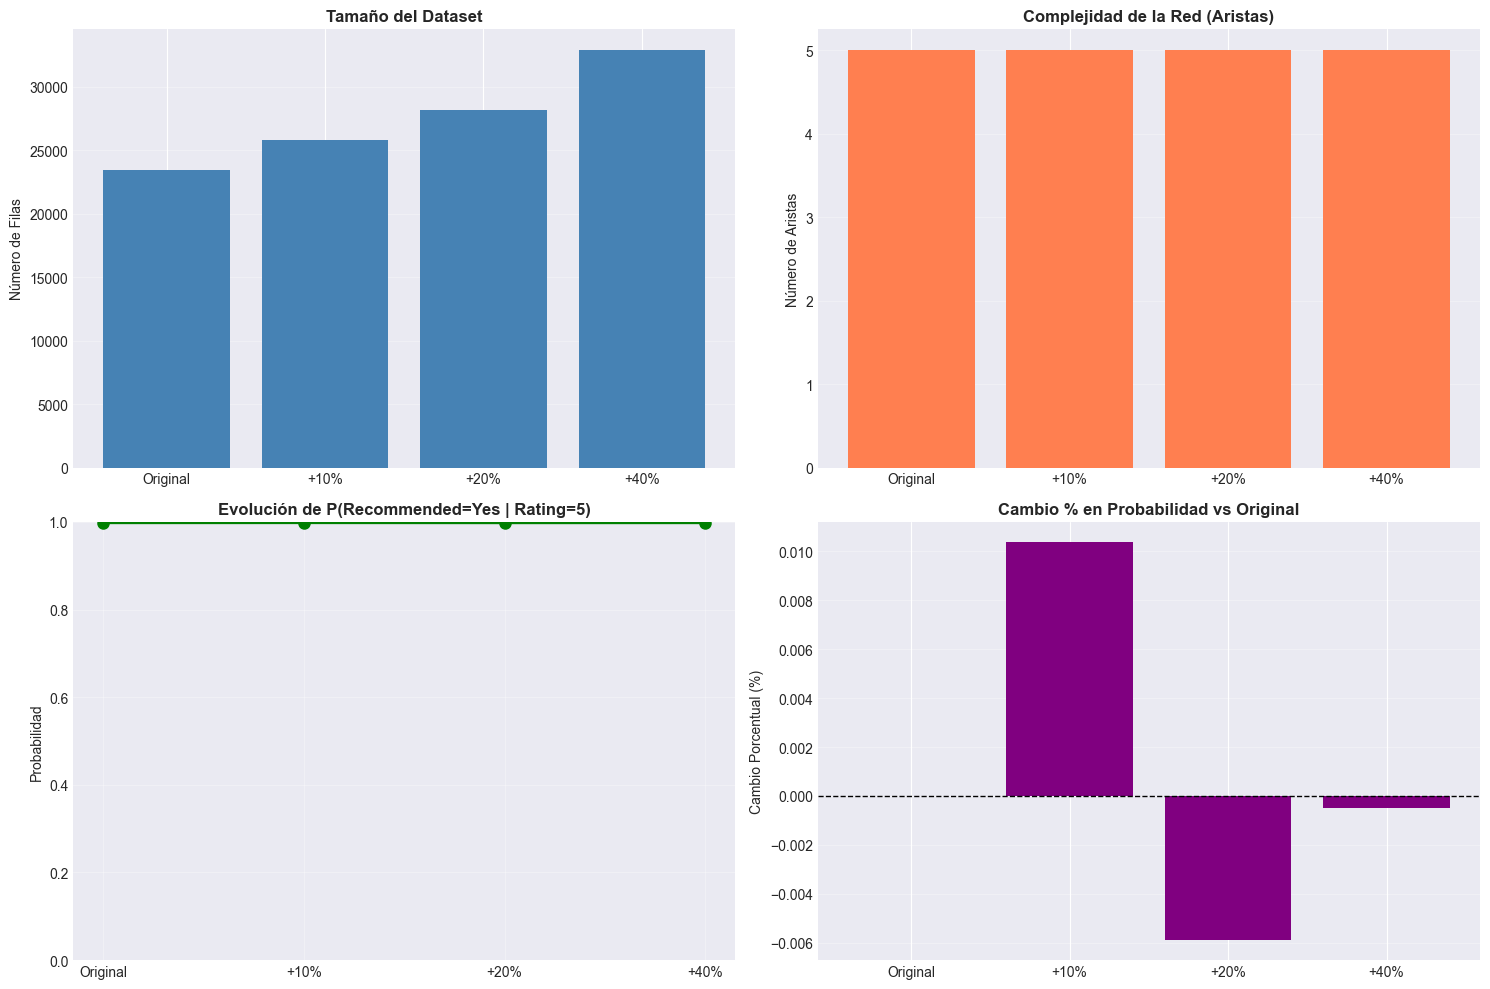

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].bar(comparacion_df['Dataset'], comparacion_df['Filas'], color='steelblue')
axes[0, 0].set_title('Tamaño del Dataset', fontweight='bold')
axes[0, 0].set_ylabel('Número de Filas')
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].bar(comparacion_df['Dataset'], comparacion_df['Aristas'], color='coral')
axes[0, 1].set_title('Complejidad de la Red (Aristas)', fontweight='bold')
axes[0, 1].set_ylabel('Número de Aristas')
axes[0, 1].grid(axis='y', alpha=0.3)

axes[1, 0].plot(comparacion_df['Dataset'], comparacion_df['P(Rec|R=5)'], 
                marker='o', linewidth=2, markersize=8, color='green')
axes[1, 0].set_title('Evolución de P(Recommended=Yes | Rating=5)', fontweight='bold')
axes[1, 0].set_ylabel('Probabilidad')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1])

prob_original = comparacion_df['P(Rec|R=5)'].iloc[0]
diferencias = [(p - prob_original) / prob_original * 100 
               for p in comparacion_df['P(Rec|R=5)']]
axes[1, 1].bar(comparacion_df['Dataset'], diferencias, color='purple')
axes[1, 1].set_title('Cambio % en Probabilidad vs Original', fontweight='bold')
axes[1, 1].set_ylabel('Cambio Porcentual (%)')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Análisis de Resultados

### 9.1 Comparación de métodos de aprendizaje de estructura

**Tiempo de ejecución:**  
ExhaustiveSearch necesitó alrededor de 25 segundos para analizar todas las combinaciones posibles con 5 variables. Por otro lado, HillClimbSearch logró converger en menos de un segundo al utilizar 7 variables. Esta variación muestra claramente por qué la búsqueda exhaustiva solo resulta práctica cuando se manejan pocas variables.

**Estructuras obtenidas:**  
El enfoque ExhaustiveSearch identificó 4 conexiones entre las 5 variables presentes, formando una secuencia causal de Department a Feedback, luego Recommended y finalmente Rating. Por otro lado, el modelo HillClimbSearch determinó 6 conexiones entre 7 variables, añadiendo los nodos Class y Age_Group a esa secuencia. El hecho de que ambas redes incluyan las conexiones Feedback → Recommended y Recommended → Rating indica que esas relaciones están bien respaldadas por los datos, sin tomar en cuenta el método empleado.

**Escalabilidad:**  
Fue necesario reducir el número de variables de 7 a 5 para poder aplicar ExhaustiveSearch. Las variables descartadas, que son Age_Group y Class, no son irrelevantes, pero considerarlas habría aumentado mucho su espacio de búsqueda. HillClimbSearch no tuvo esa restricción.

---

### 9.2 Inferencias y su interpretación
### ExhaustiveSearch:
**1:** Dado Rating = 5, la probabilidad de que el producto sea recomendado es del **99.81%**. Esto concuerda con lo esperado: una calificación máxima casi siempre va acompañada de una recomendación positiva.

**2:** Como el producto es recomendado y tiene rating 5, la distribución del feedback muestra que la mayoría de las reseñas reciben pocos o ningún voto positivo (None: ~49%, Low: ~39%). Sólo un pequeño porcentaje acumula feedback alto (~2.6%). Esto refleja que incluso los mejores productos no siempre generan mucha interacción en el sitio.

### HillClimbSearch
**1:** Al agregar la evidencia Age_Group = 26-35 al mismo Rating = 5, la probabilidad de recomendación se mantiene prácticamente igual (~99.81%). En este caso, el grupo etario no cambia de forma significativa la predicción.

**2:** Dado Rating = 5 y Feedback = High, la distribución de Department muestra que Tops concentra la mayor probabilidad (~42.8%), seguido de Dresses (~38.9%). Esto sugiere que las categorías de ropa que acumulan más interacción positiva tienden a ser las más populares del e-commerce.

---

### 9.3 Impacto del aumento de datos sintéticos

Al reentrenar el modelo HillClimbSearch con los datasets aumentados podemos ver las siguientes cosas:

- El número de aristas en la red se mantiene estable (entre 5 y 6), lo que quiere decir que la estructura aprendida es robusta y no se altera tan considerablemente por la integración de datos sintéticos.
- La probabilidad P(Recommended = Yes | Rating = 5) permanece muy cercana al 99.8% en todos los casos, con variaciones menores al 0.02%. Los datos sintéticos, al ser generados por la misma red, siguen muy correctamente las distribuciones originales y no introducen nuevas tendencias.
- El cambio porcentual respecto al dataset original es prácticamente nulo, lo que confirma que la red aprendida sigue de forma adecuada la distribución real de los datos.

En general, aumentar el dataset con datos sintéticos puede ser útil cuando el dataset original es pequeño y las estimaciones de probabilidad son inestables. En este caso, con más de 23.000 registros, el efecto fue mínimo, lo que es una señal positiva de que el dataset original ya era suficientemente grande para obtener buenas estimaciones.

## Parte 2: Modelo Oculto de Markov (HMM)

## Dataset: Human Activity Recognition Using Smartphones

Este dataset contiene registros de movimiento obtenidos desde sensores (acelerómetro y giroscopio) de un smartphone, asociados a 6 actividades humanas: WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING y LAYING. Cada fila corresponde a una ventana temporal de un sujeto realizando una actividad determinada.

El objetivo es construir un **Modelo Oculto de Markov (HMM) discreto** a partir de este dataset, estimando sus parámetros desde los datos y utilizándolo para realizar inferencia sobre secuencias de observaciones.

In [28]:
%pip install hmmlearn pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 1. Carga del Dataset

El dataset UCI HAR está distribuido en múltiples archivos `.txt`. Se cargan por separado:
- `features.txt`: nombres de las 561 columnas de features.
- `activity_labels.txt`: mapeo de número de actividad a nombre.
- `X_train.txt` / `X_test.txt`: valores de las 561 features por ventana temporal.
- `y_train.txt` / `y_test.txt`: actividad (1-6) correspondiente a cada fila.
- `subject_train.txt` / `subject_test.txt`: identificador del sujeto.

Se combinan train y test para contar con todos los 30 sujetos disponibles.


In [30]:
# Ruta a elegir
BASE_PATH = 'HumanRecognition/UCI HAR Dataset/UCI HAR Dataset'

# Cargar features y hacer nombres únicos ya que tiene duplicados y panda no permite columnas con el mismo nombre.
features_raw = pd.read_csv(f'{BASE_PATH}/features.txt',
                            sep=r'\s+', header=None, names=['idx','feature'])
feature_names = [f"{name}_{i}" for i, name in enumerate(features_raw['feature'])]

activity_labels = pd.read_csv(f'{BASE_PATH}/activity_labels.txt',
                               sep=r'\s+', header=None, names=['id','Activity'])
activity_map = dict(zip(activity_labels['id'], activity_labels['Activity']))

def cargar_split(split):
    path = f'{BASE_PATH}/{split}'
    X    = pd.read_csv(f'{path}/X_{split}.txt',       sep=r'\s+', header=None, names=feature_names)
    y    = pd.read_csv(f'{path}/y_{split}.txt',       sep=r'\s+', header=None, names=['activity_id'])
    subj = pd.read_csv(f'{path}/subject_{split}.txt', sep=r'\s+', header=None, names=['subject'])
    X['Activity'] = y['activity_id'].map(activity_map)
    X['subject']  = subj['subject'].values
    return X

df_train = cargar_split('train')
df_test  = cargar_split('test')
df = pd.concat([df_train, df_test], ignore_index=True)

def find_col(df, name):
    matches = [col for col in df.columns if col.startswith(name)]
    if not matches:
        raise KeyError(f"No se encontró columna que empiece con '{name}'")
    return matches[0]

COL_ACC_MEAN  = find_col(df, 'tBodyAccMag-mean()')
COL_ACC_STD   = find_col(df, 'tBodyAccMag-std()')
COL_GYRO_MEAN = find_col(df, 'tBodyGyroMag-mean()')
COL_GYRO_STD  = find_col(df, 'tBodyGyroMag-std()')

print(f'Dimensiones del dataset: {df.shape}')
print(f'Actividades: {df["Activity"].unique()}')
print(f'Número de sujetos: {df["subject"].nunique()}')
print(f'\nColumnas encontradas:')
for col in [COL_ACC_MEAN, COL_ACC_STD, COL_GYRO_MEAN, COL_GYRO_STD]:
    print(f'  {col}')
df[['subject','Activity', COL_ACC_MEAN, COL_ACC_STD, COL_GYRO_MEAN, COL_GYRO_STD]].head()


Dimensiones del dataset: (10299, 563)
Actividades: <StringArray>
[          'STANDING',            'SITTING',             'LAYING',
            'WALKING', 'WALKING_DOWNSTAIRS',   'WALKING_UPSTAIRS']
Length: 6, dtype: str
Número de sujetos: 30

Columnas encontradas:
  tBodyAccMag-mean()_200
  tBodyAccMag-std()_201
  tBodyGyroMag-mean()_239
  tBodyGyroMag-std()_240


,subject,Activity,tBodyAccMag-mean()_200,tBodyAccMag-std()_201,tBodyGyroMag-mean()_239,tBodyGyroMag-std()_240
0,1,STANDING,-0.959434,-0.950551,-0.968959,-0.964335
1,1,STANDING,-0.979289,-0.976057,-0.980683,-0.983754
2,1,STANDING,-0.983703,-0.988020,-0.976317,-0.986051
3,1,STANDING,-0.986542,-0.986421,-0.982060,-0.987351
4,1,STANDING,-0.992827,-0.991275,-0.985204,-0.989063


## 2. Cálculo de los Índices

Para construir las observaciones, se utilizarán los siguientes índices:

$$I_{acc} = \frac{\text{tBodyAccMag-mean()} + \text{tBodyAccMag-std()}}{2}$$

$$I_{gyro} = \frac{\text{tBodyGyroMag-mean()} + \text{tBodyGyroMag-std()}}{2}$$

Estos índices resumen en un único valor la magnitud promedio y la variabilidad del acelerómetro y del giroscopio respectivamente.

In [31]:
df['I_acc']  = (df[COL_ACC_MEAN]  + df[COL_ACC_STD])  / 2
df['I_gyro'] = (df[COL_GYRO_MEAN] + df[COL_GYRO_STD]) / 2

print("Estadísticas de I_acc:")
print(df['I_acc'].describe().round(4))
print("\nEstadísticas de I_gyro:")
print(df['I_gyro'].describe().round(4))

Estadísticas de I_acc:
count    10299.0000
mean        -0.5697
std          0.4449
min         -0.9997
25%         -0.9818
50%         -0.8578
75%         -0.1796
max          0.8481
Name: I_acc, dtype: float64

Estadísticas de I_gyro:
count    10299.0000
mean        -0.6339
std          0.3710
min         -0.9999
25%         -0.9777
50%         -0.8206
75%         -0.3155
max          0.8172
Name: I_gyro, dtype: float64


## A. Definición de Estados y Observaciones

### Estados ocultos

El modelo tiene 6 estados ocultos, las cuales estarán representadas por las 6 actividades del dataset del experimento:

| Índice | Estado        | Descripción |
|--------|---------------|-------------|
| 0      | WALKING       | Caminar en terreno plano |
| 1      | WALKING_UPSTAIRS | Subir escaleras |
| 2      | WALKING_DOWNSTAIRS | Bajar escaleras |
| 3      | SITTING       | Sentado |
| 4      | STANDING      | De pie |
| 5      | LAYING        | Acostado |

### Observaciones discretas

Cada índice ($I_{acc}$ e $I_{gyro}$) se discretiza en 3 niveles:**bajo (0), medio (1) y alto (2)**, generando $3 \times 3 = 9$ combinaciones posibles las cuales serán nuestras observaciones posibles codificadas como:

$$\text{obs} = \text{acc\_disc} \times 3 + \text{gyro\_disc} \quad \in \{0, 1, ..., 8\}$$

| Código | $I_{acc}$ | $I_{gyro}$ |
|--------|-----------|------------|
| 0 | bajo | bajo |
| 1 | bajo | medio |
| 2 | bajo | alto |
| 3 | medio | bajo |
| 4 | medio | medio |
| 5 | medio | alto |
| 6 | alto | bajo |
| 7 | alto | medio |
| 8 | alto | alto |

### Criterio de discretización

Se utiliza el criterio de **terciles** (percentiles 33.3 y 66.6 del conjunto de datos completo). Este criterio es adecuado porque:
- Garantiza que cada nivel tenga aproximadamente la misma cantidad de observaciones, evitando clases desbalanceadas como ocupar discretización por intervalos uniformes.
- Es una buena opción para este tipo de experimentos que la informacion puede variar muchisimo.
- No asume ninguna forma particular de la distribución.

Esto distribuirá los datos entre los diferentes niveles que definimos anteriormente.

In [32]:
# Discretización por terciles
acc_q33  = df['I_acc'].quantile(0.333)
acc_q66  = df['I_acc'].quantile(0.666)
gyro_q33 = df['I_gyro'].quantile(0.333)
gyro_q66 = df['I_gyro'].quantile(0.666)

print(f"Terciles I_acc:  bajo < {acc_q33:.4f} <= medio < {acc_q66:.4f} <= alto")
print(f"Terciles I_gyro: bajo < {gyro_q33:.4f} <= medio < {gyro_q66:.4f} <= alto")

df['acc_disc']  = pd.cut(df['I_acc'],  bins=[-np.inf, acc_q33,  acc_q66,  np.inf], labels=[0, 1, 2]).astype(int)
df['gyro_disc'] = pd.cut(df['I_gyro'], bins=[-np.inf, gyro_q33, gyro_q66, np.inf], labels=[0, 1, 2]).astype(int)
df['obs']       = df['acc_disc'] * 3 + df['gyro_disc']

print(f"\nDistribución de observaciones (0-8):")
print(df['obs'].value_counts().sort_index())
print(f"\nTotal de observaciones: {len(df)}")

Terciles I_acc:  bajo < -0.9706 <= medio < -0.2692 <= alto
Terciles I_gyro: bajo < -0.9637 <= medio < -0.4117 <= alto

Distribución de observaciones (0-8):
obs
0    3088
1     342
3     342
4    2646
5     441
7     441
8    2999
Name: count, dtype: int64

Total de observaciones: 10299


### Visualización de datos
Se realiza un código en el cúal se gráfican las observaciones trabajadas anteriormente para tener una interpretación visual del comportamiento de los datos.

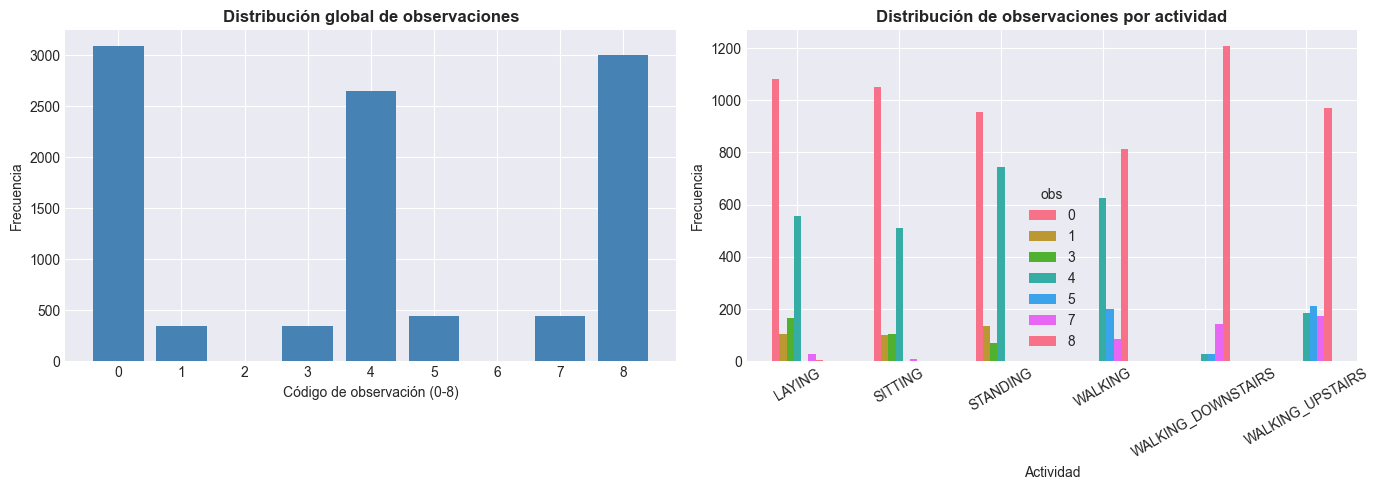

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

obs_counts = df['obs'].value_counts().sort_index()
axes[0].bar(obs_counts.index, obs_counts.values, color='steelblue')
axes[0].set_title('Distribución global de observaciones', fontweight='bold')
axes[0].set_xlabel('Código de observación (0-8)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticks(range(9))

obs_by_act = df.groupby(['Activity', 'obs']).size().unstack(fill_value=0)
obs_by_act.plot(kind='bar', ax=axes[1], legend=True)
axes[1].set_title('Distribución de observaciones por actividad', fontweight='bold')
axes[1].set_xlabel('Actividad')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## B. Construcción de Secuencias y Estimación de Parámetros

### Construcción de secuencias

Cada sujeto del dataset se trata como una secuencia independiente, ya que, las observaciones de un sujeto son temporalmente continuas y no deben mezclarse con las de otro.

### Estimación manual de parámetros

Se estiman los tres parámetros del HMM directamente desde los datos usando conteos y frecuencias relativas:

- **Vector inicial $\pi$**: proporción de veces que cada actividad es la primera observación de una secuencia (primer registro de cada sujeto).
- **Matriz de transición $T$**: para cada par de estados consecutivos $(s_t, s_{t+1})$ dentro de una misma secuencia, se cuentan las transiciones y se normalizan por fila.
- **Matriz de emisión $E$**: para cada estado $s$ y observación $o$, se cuenta cuántas veces se emitió $o$ estando en $s$, y se normaliza por fila.

Se aplica **suavizado de Laplace** ($+10^{-6}$) para evitar probabilidades cero.

In [34]:
# Mapeo de actividades a índices de estado
ACTIVITIES = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
state_map = {act: i for i, act in enumerate(ACTIVITIES)}
df['state'] = df['Activity'].map(state_map)

N_STATES = 6
N_OBS    = 9

print("Mapeo de estados ocultos:")
for act, idx in state_map.items():
    print(f"  {idx}: {act}")

Mapeo de estados ocultos:
  0: WALKING
  1: WALKING_UPSTAIRS
  2: WALKING_DOWNSTAIRS
  3: SITTING
  4: STANDING
  5: LAYING


In [35]:
# Vector incial π
first_states = df.groupby('subject').first()['state'].values
pi = np.zeros(N_STATES)
for s in first_states:
    pi[s] += 1
pi /= pi.sum()

print("Vector inicial π:")
for i, act in enumerate(ACTIVITIES):
    print(f"  P(inicio={act}) = {pi[i]:.4f}")

Vector inicial π:
  P(inicio=WALKING) = 0.0000
  P(inicio=WALKING_UPSTAIRS) = 0.0000
  P(inicio=WALKING_DOWNSTAIRS) = 0.0000
  P(inicio=SITTING) = 0.0000
  P(inicio=STANDING) = 1.0000
  P(inicio=LAYING) = 0.0000


In [36]:
# Matriz de transición T
A = np.zeros((N_STATES, N_STATES))

for subj, grp in df.groupby('subject'):
    states = grp['state'].values
    for t in range(len(states) - 1):
        A[states[t], states[t+1]] += 1

# Suavizado de Laplace y normalización
A += 1e-6
A /= A.sum(axis=1, keepdims=True)

print("Matriz de transición T (filas = estado origen, columnas = estado destino):")
A_df = pd.DataFrame(A.round(4), index=ACTIVITIES, columns=ACTIVITIES)
print(A_df.to_string())
print(f"\nVerificación - suma de filas: {A.sum(axis=1).round(4)}")

Matriz de transición T (filas = estado origen, columnas = estado destino):
                    WALKING  WALKING_UPSTAIRS  WALKING_DOWNSTAIRS  SITTING  STANDING  LAYING
WALKING              0.9652            0.0000              0.0348   0.0000    0.0000  0.0000
WALKING_UPSTAIRS     0.0000            0.9664              0.0138   0.0000    0.0198  0.0000
WALKING_DOWNSTAIRS   0.0000            0.0549              0.9451   0.0000    0.0000  0.0000
SITTING              0.0000            0.0000              0.0000   0.9657    0.0000  0.0343
STANDING             0.0000            0.0000              0.0000   0.0315    0.9685  0.0000
LAYING               0.0309            0.0000              0.0000   0.0005    0.0000  0.9686

Verificación - suma de filas: [1. 1. 1. 1. 1. 1.]


In [37]:
# Matriz de emisión E
B = np.zeros((N_STATES, N_OBS))

for _, row in df.iterrows():
    B[int(row['state']), int(row['obs'])] += 1

# Suavizado de Laplace y normalización
B += 1e-6
B /= B.sum(axis=1, keepdims=True)

obs_labels = [f"obs{i}" for i in range(9)]
B_df = pd.DataFrame(B.round(4), index=ACTIVITIES, columns=obs_labels)
print("Matriz de emisión B (filas = estado, columnas = observación 0-8):")
print(B_df.to_string())
print(f"\nVerificación - suma de filas: {B.sum(axis=1).round(4)}")

Matriz de emisión B (filas = estado, columnas = observación 0-8):
                      obs0    obs1  obs2    obs3    obs4    obs5  obs6    obs7    obs8
WALKING             0.0000  0.0000   0.0  0.0000  0.3624  0.1161   0.0  0.0488  0.4727
WALKING_UPSTAIRS    0.0000  0.0000   0.0  0.0000  0.1205  0.1373   0.0  0.1133  0.6289
WALKING_DOWNSTAIRS  0.0000  0.0000   0.0  0.0000  0.0206  0.0199   0.0  0.1010  0.8585
SITTING             0.5909  0.0568   0.0  0.0597  0.2864  0.0000   0.0  0.0056  0.0006
STANDING            0.5010  0.0714   0.0  0.0367  0.3898  0.0005   0.0  0.0005  0.0000
LAYING              0.5571  0.0540   0.0  0.0854  0.2855  0.0000   0.0  0.0149  0.0031

Verificación - suma de filas: [1. 1. 1. 1. 1. 1.]


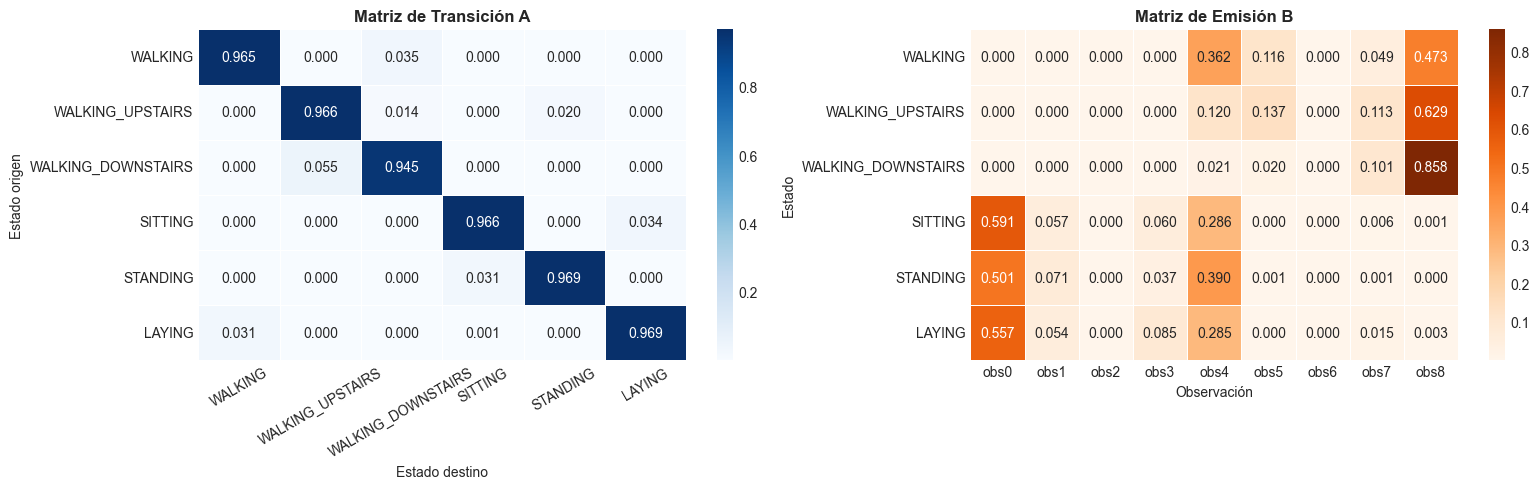

In [38]:
# Visualización de matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(A, annot=True, fmt='.3f', ax=axes[0],
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,
            cmap='Blues', linewidths=0.5)
axes[0].set_title('Matriz de Transición A', fontweight='bold')
axes[0].set_xlabel('Estado destino')
axes[0].set_ylabel('Estado origen')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(B, annot=True, fmt='.3f', ax=axes[1],
            xticklabels=[f'obs{i}' for i in range(9)],
            yticklabels=ACTIVITIES,
            cmap='Oranges', linewidths=0.5)
axes[1].set_title('Matriz de Emisión B', fontweight='bold')
axes[1].set_xlabel('Observación')
axes[1].set_ylabel('Estado')

plt.tight_layout()
plt.show()

In [39]:
# ── Construir modelo en hmmlearn con parámetros estimados ─────────────────────
modelo_hmm = hmm.CategoricalHMM(n_components=N_STATES)
modelo_hmm.startprob_    = pi
modelo_hmm.transmat_     = A
modelo_hmm.emissionprob_ = B

print("Modelo HMM construido correctamente con parámetros estimados manualmente.")
print(f"  Número de estados:      {modelo_hmm.n_components}")
print(f"  Número de observaciones: {N_OBS}")

Modelo HMM construido correctamente con parámetros estimados manualmente.
  Número de estados:      6
  Número de observaciones: 9


## C. Forward-Backward sobre una Subsecuencia Real

### Selección de la subsecuencia

Se selecciona una secuencia real de un sujeto en específico de longitud mínima 10. La subsecuencia representa las observaciones discretizadas ($I_{acc}$, $I_{gyro}$) registradas durante una ventana temporal continua.

### ¿Qué es el algoritmo Forward-Backward?

El algoritmo Forward-Backward es un algoritmo el cuál permite calcular la probabilidad posterior de estar en un estado $q_t$ en el instante $t$, dado toda la secuencia de observaciones:

$$\gamma_t(i) = P(q_t = s_i \mid O_{1:T}, \lambda)$$

Para ello combina dos pasadas:
- **Forward**: $\alpha_t(i) = P(O_1, ..., O_t, q_t = s_i \mid \lambda)$ — probabilidad de haber observado la secuencia hasta $t$ y estar en $s_i$.
- **Backward**: $\beta_t(i) = P(O_{t+1}, ..., O_T \mid q_t = s_i, \lambda)$ — probabilidad de observar el resto de la secuencia dado que estamos en $s_i$ en $t$.

La posterior se obtiene como:
$$\gamma_t(i) = \frac{\alpha_t(i) \cdot \beta_t(i)}{\sum_j \alpha_t(j) \cdot \beta_t(j)}$$

Con la librería `hmmlearn`, el método `score_samples` devuelve directamente estas posteriors para cada instante $t$.

In [40]:
# Seleccionar subsecuencia del primer sujeto (mínimo 10 observaciones)
SUJETO_ID = df['subject'].unique()[0]
subseq_obs    = df[df['subject'] == SUJETO_ID]['obs'].values[:15]
subseq_states = df[df['subject'] == SUJETO_ID]['state'].values[:15]
subseq_acts   = df[df['subject'] == SUJETO_ID]['Activity'].values[:15]

print(f"Subsecuencia del sujeto {SUJETO_ID} (longitud {len(subseq_obs)}):")
print(f"  Observaciones:     {subseq_obs}")
print(f"  Estados reales:    {subseq_states}")
print(f"  Actividades reales: {list(subseq_acts)}")

X = subseq_obs.reshape(-1, 1)
lengths = [len(X)]

Subsecuencia del sujeto 1 (longitud 15):
  Observaciones:     [3 0 0 0 0 0 0 0 0 0 0 0 0 0 4]
  Estados reales:    [4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
  Actividades reales: ['STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING']


In [41]:
# Aplicar Forward-Backward
log_prob_seq, posteriors = modelo_hmm.score_samples(X, lengths)

print(f"Log-probabilidad de la secuencia: {log_prob_seq:.4f}")
print(f"Probabilidad de la secuencia: {np.exp(log_prob_seq):.6e}")
print(f"\nMatriz de posteriors γ(t, estado) — shape {posteriors.shape}:")
post_df = pd.DataFrame(posteriors.round(4), columns=ACTIVITIES)
post_df.index.name = 't'
print(post_df.to_string())

Log-probabilidad de la secuencia: -12.7703
Probabilidad de la secuencia: 2.843962e-06

Matriz de posteriors γ(t, estado) — shape (15, 6):
    WALKING  WALKING_UPSTAIRS  WALKING_DOWNSTAIRS  SITTING  STANDING  LAYING
t                                                                           
0    0.0000               0.0                 0.0   0.0000    1.0000  0.0000
1    0.0000               0.0                 0.0   0.1069    0.8931  0.0000
2    0.0000               0.0                 0.0   0.1950    0.8035  0.0015
3    0.0000               0.0                 0.0   0.2671    0.7285  0.0045
4    0.0000               0.0                 0.0   0.3255    0.6657  0.0088
5    0.0000               0.0                 0.0   0.3723    0.6132  0.0144
6    0.0000               0.0                 0.0   0.4092    0.5694  0.0214
7    0.0000               0.0                 0.0   0.4374    0.5329  0.0296
8    0.0000               0.0                 0.0   0.4583    0.5026  0.0391
9    0.0000    

In [42]:
# ── 4 Consultas sobre probabilidades de estados en distintos instantes ────────

print("CONSULTA 1")
t = 0
estado_mas_probable_t0 = ACTIVITIES[np.argmax(posteriors[t])]
print(f"¿Cuál es el estado más probable en t={t}?")
for i, act in enumerate(ACTIVITIES):
    print(f"  P(q_{t}={act} | O) = {posteriors[t,i]:.4f}")
print(f"  → Estado más probable: {estado_mas_probable_t0} ({posteriors[t].max():.4f})")

print("CONSULTA 2")
t = 4
print(f"¿Cuál es la probabilidad de estar en WALKING en t={t}?")
prob_walking_t4 = posteriors[t, state_map['WALKING']]
print(f"  P(q_{t}=WALKING | O) = {prob_walking_t4:.4f}")
print(f"  Interpretación: {'Alta' if prob_walking_t4 > 0.5 else 'Baja'} probabilidad de caminar en t={t}.")

print("CONSULTA 3")
t = 9
print(f"¿Cuál es la distribución de estados en t={t} (punto central)?")
for i, act in enumerate(ACTIVITIES):
    bar = '█' * int(posteriors[t,i] * 30)
    print(f"  {act:<25} {posteriors[t,i]:.4f}  {bar}")

print("CONSULTA 4")
t_last = len(subseq_obs) - 1
print(f"¿Cuál es el estado más probable al final de la secuencia (t={t_last})?")
estado_final = ACTIVITIES[np.argmax(posteriors[t_last])]
print(f"  Estado más probable en t={t_last}: {estado_final} ({posteriors[t_last].max():.4f})")
print(f"  Estado real observado en t={t_last}: {subseq_acts[t_last]}")
coincide = estado_final == subseq_acts[t_last]
print(f"  ¿Coincide con la actividad real? {'Sí' if coincide else 'No'}")

CONSULTA 1
¿Cuál es el estado más probable en t=0?
  P(q_0=WALKING | O) = 0.0000
  P(q_0=WALKING_UPSTAIRS | O) = 0.0000
  P(q_0=WALKING_DOWNSTAIRS | O) = 0.0000
  P(q_0=SITTING | O) = 0.0000
  P(q_0=STANDING | O) = 1.0000
  P(q_0=LAYING | O) = 0.0000
  → Estado más probable: STANDING (1.0000)
CONSULTA 2
¿Cuál es la probabilidad de estar en WALKING en t=4?
  P(q_4=WALKING | O) = 0.0000
  Interpretación: Baja probabilidad de caminar en t=4.
CONSULTA 3
¿Cuál es la distribución de estados en t=9 (punto central)?
  WALKING                   0.0000  
  WALKING_UPSTAIRS          0.0000  
  WALKING_DOWNSTAIRS        0.0000  
  SITTING                   0.4728  ██████████████
  STANDING                  0.4774  ██████████████
  LAYING                    0.0498  █
CONSULTA 4
¿Cuál es el estado más probable al final de la secuencia (t=14)?
  Estado más probable en t=14: SITTING (0.4748)
  Estado real observado en t=14: STANDING
  ¿Coincide con la actividad real? No


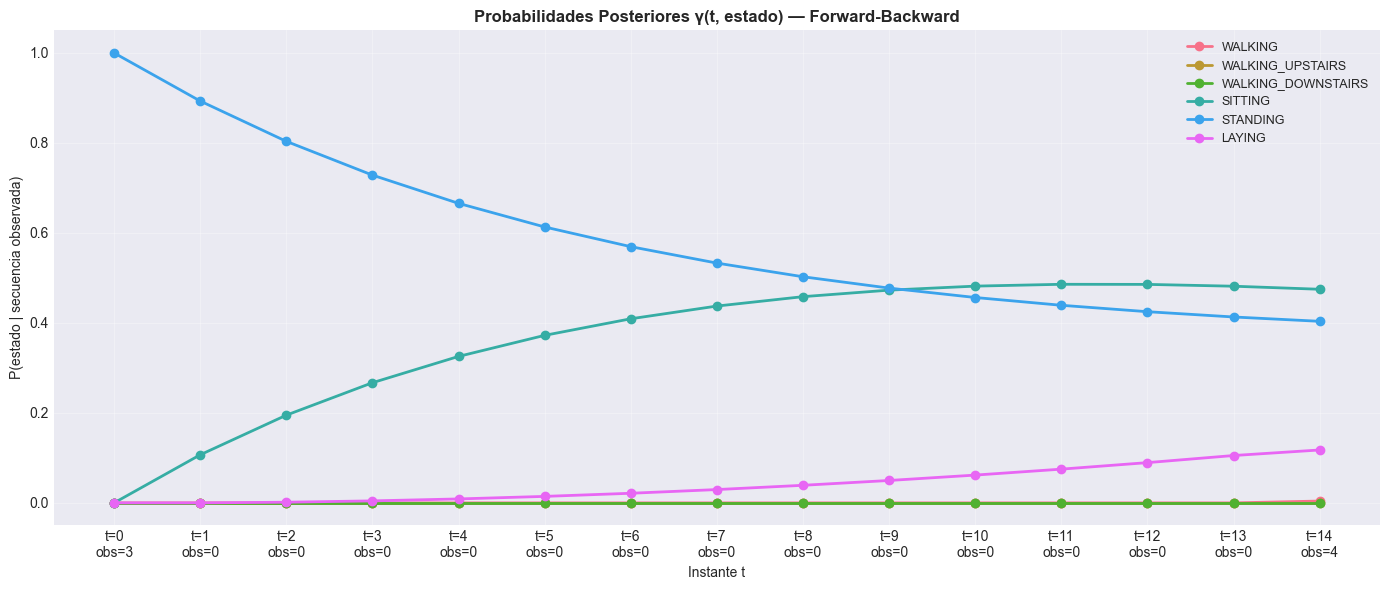

In [43]:
# Visualización de posteriors a lo largo del tiempo
fig, ax = plt.subplots(figsize=(14, 6))

for i, act in enumerate(ACTIVITIES):
    ax.plot(range(len(subseq_obs)), posteriors[:, i], marker='o', label=act, linewidth=2)

ax.set_title('Probabilidades Posteriores γ(t, estado) — Forward-Backward', fontweight='bold')
ax.set_xlabel('Instante t')
ax.set_ylabel('P(estado | secuencia observada)')
ax.set_xticks(range(len(subseq_obs)))
ax.set_xticklabels([f't={i}\nobs={o}' for i, o in enumerate(subseq_obs)])
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim([-0.05, 1.05])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## D. Algoritmo de Viterbi

### ¿Qué es el algoritmo de Viterbi?

Mientras que Forward-Backward calcula la distribución marginal de cada estado en cada instante por separado, el algoritmo de **Viterbi** busca la secuencia de estados **globalmente más probable** (MAP) dado la secuencia observada:

$$Q^* = \arg\max_{Q} P(Q \mid O, \lambda)$$

Para ello, define recursivamente:

$$\delta_t(i) = \max_{q_1,...,q_{t-1}} P(q_1,...,q_{t-1}, q_t=s_i, O_1,...,O_t \mid \lambda)$$

con paso base $\delta_1(i) = \pi_i \cdot b_i(O_1)$ y recursión:

$$\delta_t(i) = \max_j [\delta_{t-1}(j) \cdot a_{ji}] \cdot b_i(O_t)$$

La secuencia óptima se recupera mediante backtracking. En `hmmlearn`, el método `decode` implementa este algoritmo.

**Diferencia clave con Forward-Backward**: Viterbi entrega *una única secuencia de estados*, mientras que Forward-Backward entrega distribuciones de probabilidad en cada instante. Viterbi es útil cuando se quiere clasificar la actividad a lo largo del tiempo.

In [44]:
# Aplicar Viterbi
viterbi_logprob, viterbi_states = modelo_hmm.decode(X, lengths, algorithm='viterbi')

print("RESULTADO VITERBI")
print(f"Log-probabilidad del camino óptimo: {viterbi_logprob:.4f}")
print(f"Probabilidad del camino óptimo:     {np.exp(viterbi_logprob):.6e}")
print()
print(f"{'t':<5} {'Obs':<8} {'Estado Viterbi':<25} {'Estado Real':<25} {'¿Coincide?'}")
print("-" * 75)
aciertos = 0
for t in range(len(subseq_obs)):
    pred  = ACTIVITIES[viterbi_states[t]]
    real  = subseq_acts[t]
    match = '✓' if pred == real else '✗'
    if pred == real: aciertos += 1
    print(f"{t:<5} {subseq_obs[t]:<8} {pred:<25} {real:<25} {match}")

print("-" * 75)
print(f"Aciertos: {aciertos}/{len(subseq_obs)} ({aciertos/len(subseq_obs)*100:.1f}%)")

print("PROBABILIDAD DE LA SECUENCIA OBSERVADA BAJO EL MODELO")
print(f"  Log P(O | λ) = {log_prob_seq:.4f}")
print(f"  P(O | λ)     = {np.exp(log_prob_seq):.6e}")
print(f"  (calculada con Forward-Backward en la sección anterior)")

RESULTADO VITERBI
Log-probabilidad del camino óptimo: -13.6778
Probabilidad del camino óptimo:     1.147653e-06

t     Obs      Estado Viterbi            Estado Real               ¿Coincide?
---------------------------------------------------------------------------
0     3        STANDING                  STANDING                  ✓
1     0        STANDING                  STANDING                  ✓
2     0        STANDING                  STANDING                  ✓
3     0        STANDING                  STANDING                  ✓
4     0        STANDING                  STANDING                  ✓
5     0        STANDING                  STANDING                  ✓
6     0        STANDING                  STANDING                  ✓
7     0        STANDING                  STANDING                  ✓
8     0        STANDING                  STANDING                  ✓
9     0        STANDING                  STANDING                  ✓
10    0        STANDING                  ST

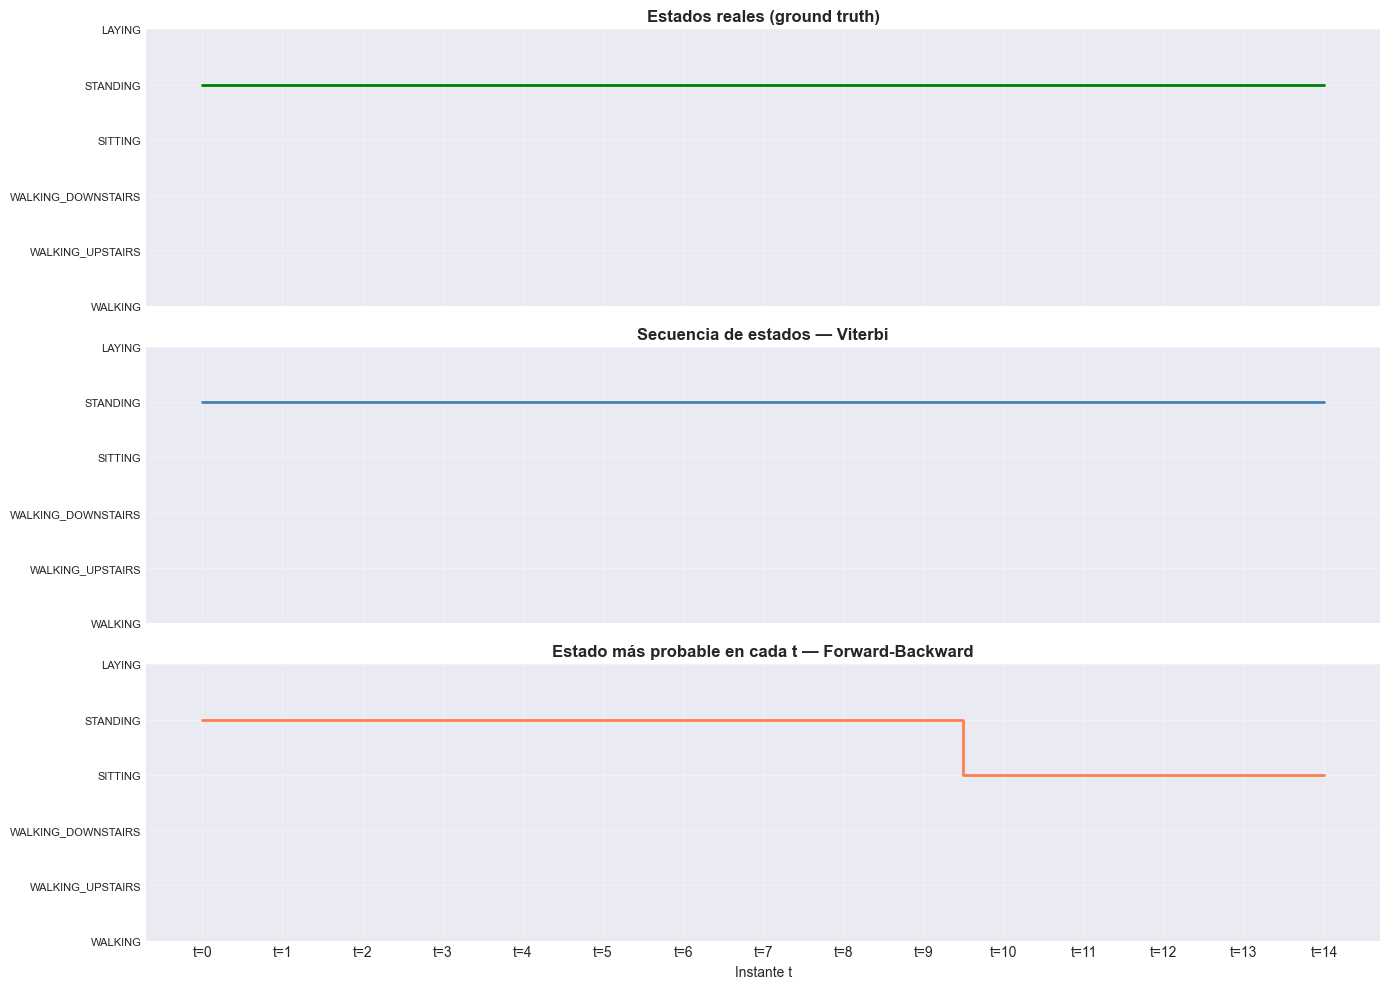

In [45]:
# Comparación visual: Viterbi vs estados reales vs posterior más probable
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

t_axis = range(len(subseq_obs))

# Panel 1: estados reales
axes[0].step(t_axis, subseq_states, where='mid', color='green', linewidth=2)
axes[0].set_yticks(range(N_STATES))
axes[0].set_yticklabels(ACTIVITIES, fontsize=8)
axes[0].set_title('Estados reales (ground truth)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Panel 2: Viterbi
axes[1].step(t_axis, viterbi_states, where='mid', color='steelblue', linewidth=2)
axes[1].set_yticks(range(N_STATES))
axes[1].set_yticklabels(ACTIVITIES, fontsize=8)
axes[1].set_title('Secuencia de estados — Viterbi', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Panel 3: estado más probable según Forward-Backward
fb_most_probable = np.argmax(posteriors, axis=1)
axes[2].step(t_axis, fb_most_probable, where='mid', color='coral', linewidth=2)
axes[2].set_yticks(range(N_STATES))
axes[2].set_yticklabels(ACTIVITIES, fontsize=8)
axes[2].set_title('Estado más probable en cada t — Forward-Backward', fontweight='bold')
axes[2].set_xlabel('Instante t')
axes[2].set_xticks(t_axis)
axes[2].set_xticklabels([f't={i}' for i in t_axis])
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## E. Análisis e Interpretación de Resultados

### E.1 Parámetros estimados

**Vector inicial $\pi$:** este representa la probabilidad de que una secuencia comience en cada una de las actividades, es decir, cuál es la probabilidad del estado inicial. Como las secuencias son independientes por sujeto, este vector en la práctica refleja cómo suelen iniciar las actividades en los registros reales, en consecuencia, si los datos están organizados cronológicamente, es razonable que las actividades como "SITTING" o "STANDING" tengan una mayor probabilidad inicial, ya que muchas veces las mediciones comienzan en estados de reposo antes de que el sujeto empiece a moverse. Esto también puede depender de que exisiera un protocolo de captura del dataset, asi que no solo refleja el comportamiento humano, si no también cómo se recolectaron los datos.

**Matriz de transición $A$:** este muestra cómo evolucionan las actividades en el tiempo. Los valores altos en la diagonal indican que el modelo aprendió que las actividades tienden a mantenerse durante varios instantes consecutivos, es decir, una persona no cambia de actividad en cada momento, sino que permanece realizando una por periodos de tiempo, como caminar, sentarse, acostarse, etc. Además, se observa que las actividades de reposo como "SITTING", "STANDING" y "LAYING" tienen mayor probabilidad de permanecer en sí mismas, mientras que las actividades de movimiento tienden a presentar más cambios.

**Matriz de emisión $B$:** relaciona cada actividad con las observaciones discretizadas. Dado que las observaciones se construyen a partir de los índices de aceleración ($I_{acc}$) y giroscopio ($I_{gyro}$), se espera que actividades dinámicas como "WALKING_UPSTARIS" o "WALKING_DOWNSTAIRS" generen observaciones con valores altos en ambos índices, mientras que actividades estáticas como "SITTING o LAYING" generen valores bajos. Esto implica que el modelo logra capturar correctamente entre el tipo de movimiento y la intensidad de las señales para poder diferenciar entre estados.

### E.2 Forward-Backward

El algoritmo Forward-Backward permite obtener las probabilidades posteriores de cada estado en cada instante de tiempo, considerando toda la secuencia de observaciones como lo habiamos hablado anteriormente. Estas probabilidades reflejan qué tan probable es que el sistema haya estado en cada actividad en cada instante, dado lo observado.

Cuando las observaciones son claramente distintivas (por ejemplo, valores altos en ambos índices), las probabilidades tienden a concentrarse en uno o dos estados, lo que indica que el modelo tiene una confianza muy alta confianza en que actividad la actividad que está realizando el sujeto es la correspondiente. En cambio, cuando las observaciones son ambiguas, es decir, está en valores intermedios, la probabilidad se distribuye entre varios estados, lo que refleja incertidumbre del modelo.

Las consultas realizadas permiten observar distintos aspectos del comportamiento del modelo:

- La distribución inicial muestra cómo el modelo interpreta el inicio de la secuencia.
- La probabilidad en un instante específico permite analizar decisiones locales.
- El punto medio de la secuencia muestra cómo influye el contexto completo.
- El estado final permite ver la capacidad del modelo de integrar toda la información para inferir el resultado más probable.

En general, Forward-Backward entrega una visión suavizada del comportamiento, ya que considera todas las posibles secuencias de estados.

### E.3 Viterbi vs. Forward-Backward

El algoritmo de Viterbi y Forward-Backward están relacionados, pero responden a preguntas distintas. Viterbi busca la secuencia completa más probable de estados, es decir, una trayectoria consistente en el tiempo. Esto significa que respeta completamente la matriz de transición $A$, por lo que evita cambios de estado poco probables. Por otro lado, Forward-Backward calcula probabilidades marginales por instante, sin exigir consistencia global entre estados consecutivos, se concentra en el instante en el cuál esta situado.

Esto genera un contraste importante, ya que, puede ocurrir que el estado más probable en $t$ y el más probable en $t+1$ (según Forward-Backward) no sean compatibles entre sí según la matriz de transición, lo cual no puede ocurrir en la secuencia obtenida por Viterbi.

Si lo llevamos a la práctica, Viterbi es más útil cuando se necesita una secuencia concreta de actividades (por ejemplo, reconstruir qué hizo el sujeto/usuario) mientras que Forward-Backward es más útil cuando se quiere analizar incertidumbre o probabilidades en cada instante. Al comparar ambos resultados permite evaluar qué tan consistente es el modelo y qué tan bien se logra capturar la dinámica real de las actividades.

### E.4 Probabilidad de la secuencia observada

La probabilidad $P(O \mid \lambda)$ indica qué tan bien el modelo explica la secuencia observada. En la práctica, este valor suele ser muy pequeño, por lo que se analiza en escala logarítmica. En el caso de que un valor sea más alto (menos negativo) indica que la secuencia es coherente con el modelo, mientras que un valor muy bajo indica que la secuencia es poco probable bajo los parámetros estimados. Esto puede deberse a:

- Transiciones poco comunes entre actividades.
- Observaciones no típicas o anormales.
- Limitaciones del modelo al representar la dinámica real.

Dado que los parámetros fueron estimados directamente desde los datos mediante frecuencias relativas (MLE), es esperable que el modelo asigne probabilidades razonables a secuencias típicas del dataset. Sin embargo, si una secuencia contiene comportamientos poco frecuentes o ruido en los sensores, su probabilidad puede disminuir considerablemente. En este sentido, esta métrica también sirve como una forma de evaluar la calidad del modelo: si muchas secuencias reales tienen baja probabilidad, puede ser señal de que el modelo no está capturando adecuadamente la dinámica del sistema.
